# Concept Attribution (LRP + RelMax)

This is an extended natural-image visualisation. For the canonical declared workflow with a two-pass preflight plan and named TensorDict artifacts, start with [Declared Pipelines](../../declared-pipelines.html).

This tutorial walks through a simple concept attribution pipeline with **VGG16**.

We will:
- define a binary concept (**striped** vs non-striped) from a small DTD subset,
- compute channel relevance scores with **LRP**,
- select the most concept-relevant channel with **RelMax(1)**,
- visualize concept-conditioned relevance maps on local asset images.

This decomposition is inspired by Concept Relevance Propagation (CRP) <cite data-cite="Achtibat2022FromAM">(Achtibat et al. 2022)</cite>.

## Setup

In [1]:
import importlib.util

DEV = True

if importlib.util.find_spec("google.colab") is not None:
    MODE = "colab-dev" if DEV else "colab"
else:
    MODE = "local"

In [2]:
if MODE == "colab":
    %pip install -q tdhook
elif MODE == "colab-dev":
    !rm -rf tdhook
    !git clone https://github.com/Xmaster6y/tdhook -b main
    %pip install -q ./tdhook

## Imports

In [3]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import timm
import torch
from datasets import load_dataset
from PIL import Image
from tensordict import TensorDict

from tdhook.attribution.lrp import LRP
from tdhook.attribution.lrp_helpers.rules import EpsilonPlus, Rule
from tdhook.latent.activation_caching import ActivationCaching

## Load VGG16 and preprocessing

We use ImageNet-pretrained `vgg16.tv_in1k` and make ReLU layers non-inplace for attribution compatibility.

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
layer_number = 28

model = timm.create_model("vgg16.tv_in1k", pretrained=True)
for name, module in model.named_modules():
    if isinstance(module, torch.nn.ReLU):
        *parts, last = name.split(".")
        submodule = model
        for part in parts:
            submodule = getattr(submodule, part)
        setattr(submodule, last, torch.nn.ReLU(inplace=False))

model.to(device)
model.eval()

data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)

device

'cpu'

## 1) Define the concept dataset (striped vs non-striped)

We build a tiny, balanced concept set from DTD train split.

In [5]:
concept_name = "striped"
num_samples_per_class = 20

dtd = load_dataset("tanganke/dtd", split="train")
concept_idx = dtd.features["label"].names.index(concept_name)

positive_indices = [i for i, item in enumerate(dtd) if item["label"] == concept_idx]
negative_indices = [i for i, item in enumerate(dtd) if item["label"] != concept_idx]

positive_indices = random.sample(positive_indices, num_samples_per_class)
negative_indices = random.sample(negative_indices, num_samples_per_class)

concept_examples = []
for idx in positive_indices:
    concept_examples.append({"image": dtd[idx]["image"], "label": 1})
for idx in negative_indices:
    concept_examples.append({"image": dtd[idx]["image"], "label": 0})

random.shuffle(concept_examples)
len(concept_examples)

40

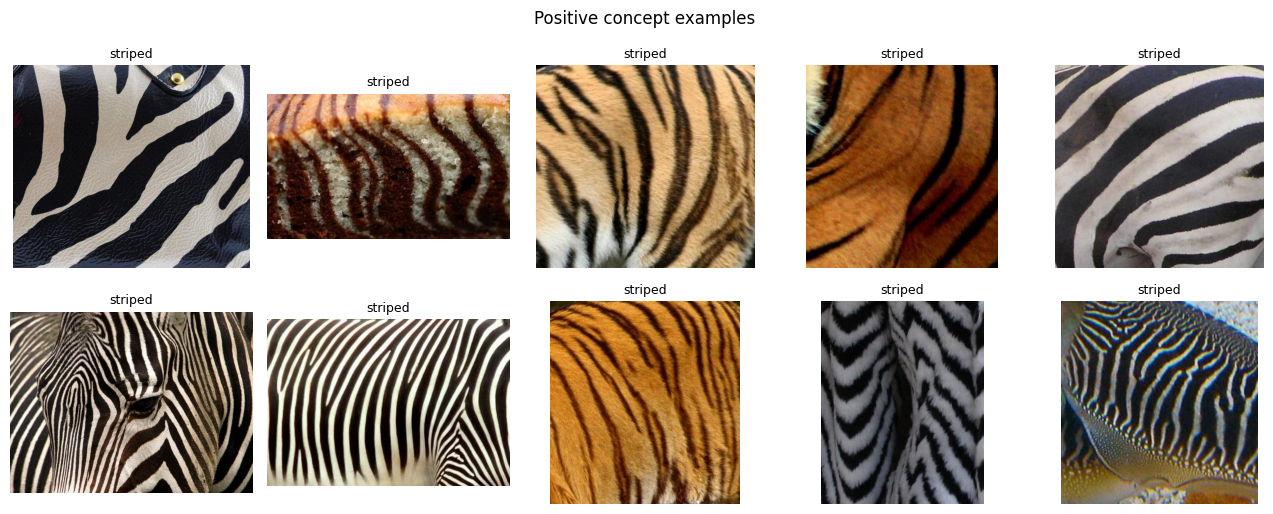

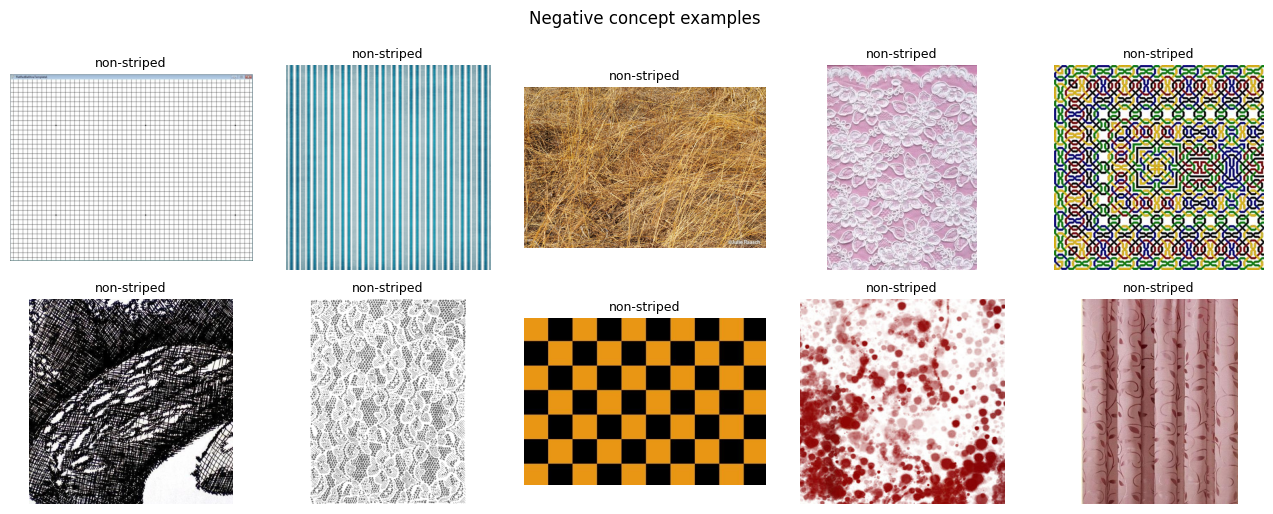

In [6]:
def show_concept_grid(samples, title, n_cols=5):
    n = len(samples)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 2.6 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle(title)

    for i in range(n_rows * n_cols):
        ax = axes[i // n_cols, i % n_cols]
        if i < n:
            ax.imshow(samples[i]["image"])
            ax.set_title("striped" if samples[i]["label"] == 1 else "non-striped", fontsize=9)
        ax.axis("off")
    plt.tight_layout()


show_concept_grid([x for x in concept_examples if x["label"] == 1][:10], "Positive concept examples")
show_concept_grid([x for x in concept_examples if x["label"] == 0][:10], "Negative concept examples")

## 2) Compute RelMax(1) concept channel

We compute per-channel relevance at `features.28` and rank channels by:

`mean_relevance(striped) - mean_relevance(non-striped)`

The top channel is RelMax(1).

In [7]:
class CustomEpsilonPlus(EpsilonPlus):
    def _call(self, name: str, module: torch.nn.Module) -> Rule | None:
        if isinstance(module, (timm.models.vgg.ConvMlp, timm.layers.ClassifierHead, timm.layers.SelectAdaptivePool2d)):
            return self._rules["ignore"]
        return super()._call(name, module)


def preprocess_batch(pil_images):
    return torch.stack([transforms(im.convert("RGB")) for im in pil_images], dim=0)


def init_max_logit_targets(targets, _):
    output = targets["output"]
    max_logit = output.max(dim=-1).values
    return TensorDict(out=max_logit, batch_size=targets.batch_size)


def collect_layer_relevances(samples, batch_size=8):
    module_key = f"features.{layer_number}"
    lrp = LRP(
        init_attr_targets=init_max_logit_targets,
        rule_mapper=CustomEpsilonPlus(epsilon=1e-6),
        skip_modules=LRP.default_skip,
        input_modules=[module_key],
        clean_intermediate_keys=False,
    )

    relevances = []
    labels = []
    with lrp.prepare(model) as hooked_model:
        for start in range(0, len(samples), batch_size):
            chunk = samples[start : start + batch_size]
            images = preprocess_batch([x["image"] for x in chunk]).to(device)
            td = TensorDict({"input": images}, batch_size=images.shape[0])
            td = hooked_model(td)

            batch_rel = td.get(("attr", module_key)).sum(dim=(2, 3)).abs().cpu()
            batch_labels = torch.tensor([x["label"] for x in chunk], dtype=torch.long)
            relevances.append(batch_rel)
            labels.append(batch_labels)

    return torch.cat(relevances, dim=0), torch.cat(labels, dim=0)


relevances, concept_labels = collect_layer_relevances(concept_examples)
pos_mean = relevances[concept_labels == 1].mean(dim=0)
neg_mean = relevances[concept_labels == 0].mean(dim=0)
channel_scores = pos_mean - neg_mean
relmax_channel = int(channel_scores.argmax().item())

print(f"Selected RelMax(1) channel: {relmax_channel}")

Selected RelMax(1) channel: 90


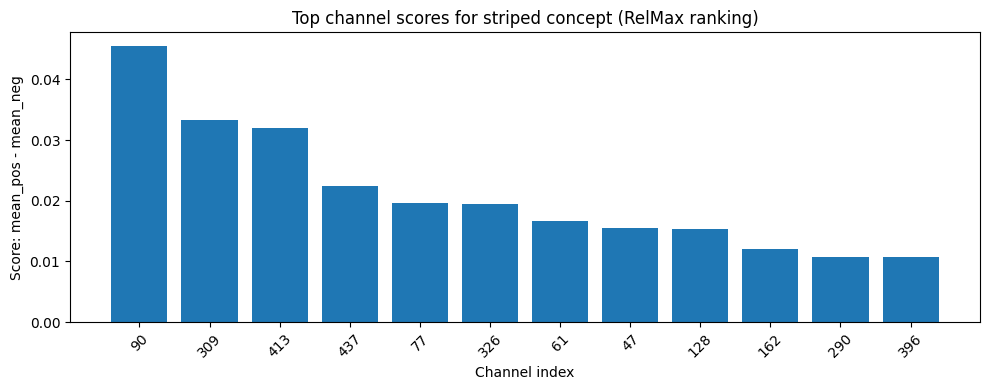

In [8]:
top_k = 12
top_indices = torch.argsort(channel_scores, descending=True)[:top_k]
top_values = channel_scores[top_indices].numpy()

plt.figure(figsize=(10, 4))
plt.bar([str(int(i)) for i in top_indices], top_values)
plt.title("Top channel scores for striped concept (RelMax ranking)")
plt.xlabel("Channel index")
plt.ylabel("Score: mean_pos - mean_neg")
plt.xticks(rotation=45)
plt.tight_layout()

## 3) Compute concept attribution on local assets

For each image, we compute:
- standard input relevance map (LRP),
- concept-conditioned relevance map (same LRP, but gradients are restricted to RelMax(1) channel at `features.28`).

In [9]:
asset_dir = Path("../assets")
asset_files = [
    "lemur_1.jpg",
    "lemur_2.jpg",
    "skunk_1.jpg",
    "skunk_2.jpg",
    "zebra_2.jpg",
]

target_map = {
    "lemur": 383,
    "skunk": 361,
    "zebra": 340,
}


def target_class_from_name(filename, logits):
    stem = filename.split("_")[0]
    if stem in target_map:
        return target_map[stem]
    return int(logits.argmax(dim=-1).item())


def normalize_heatmap(hm):
    abs_max = np.abs(hm).max()
    if abs_max > 0:
        return hm / abs_max
    return hm


def make_channel_callback(channel_idx, n_channels):
    def grad_callback(grad_output, **kwargs):
        grad = grad_output[0]
        mask = torch.zeros((1, n_channels, 1, 1), device=grad.device, dtype=grad.dtype)
        mask[:, channel_idx] = 1
        return (grad * mask,)

    return grad_callback


def run_lrp_on_image(image_tensor, target_class, grad_callback=None):
    module_key = f"features.{layer_number}"

    def init_targets(targets, _):
        score = targets["output"][..., target_class]
        return TensorDict(out=score, batch_size=targets.batch_size)

    kwargs = {
        "init_attr_targets": init_targets,
        "rule_mapper": CustomEpsilonPlus(epsilon=1e-6),
        "skip_modules": LRP.default_skip,
        "clean_intermediate_keys": False,
    }
    if grad_callback is not None:
        kwargs["output_grad_callbacks"] = {module_key: grad_callback}

    lrp = LRP(**kwargs)
    with lrp.prepare(model) as hooked_model:
        td = TensorDict({"input": image_tensor.unsqueeze(0).to(device)}, batch_size=1)
        td = hooked_model(td)
        map_2d = td.get(("attr", "input")).squeeze(0).sum(dim=0).abs().detach().cpu().numpy()
    return map_2d


with ActivationCaching(f"features.{layer_number}").prepare(model) as cache_model:
    dummy = TensorDict(
        {"input": torch.zeros(1, 3, data_config["input_size"][1], data_config["input_size"][2], device=device)},
        batch_size=1,
    )
    cache_model(dummy)
    n_channels = cache_model.hooking_context.cache[f"features.{layer_number}"].shape[1]

channel_callback = make_channel_callback(relmax_channel, n_channels)

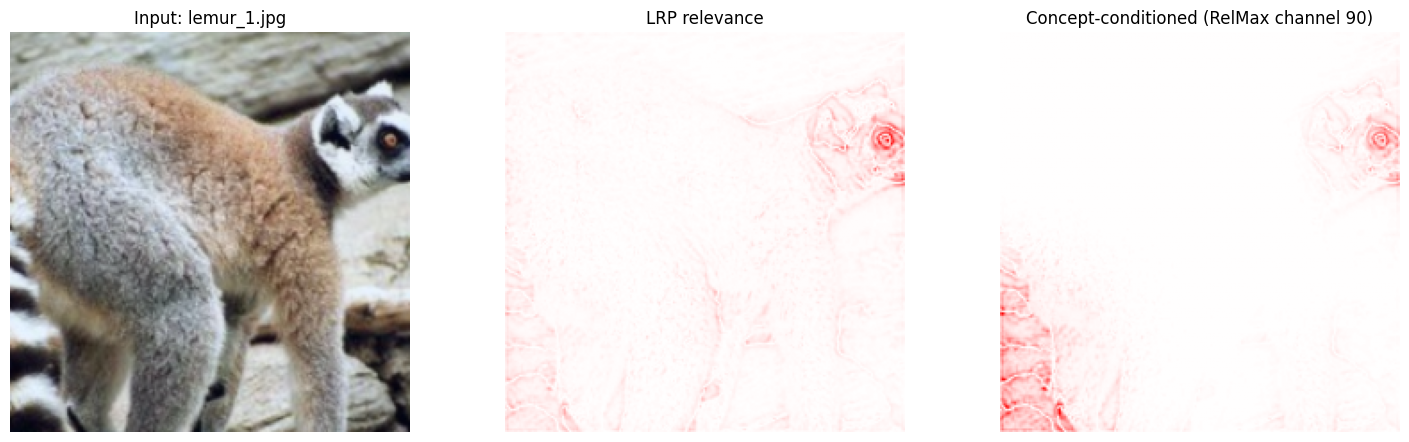

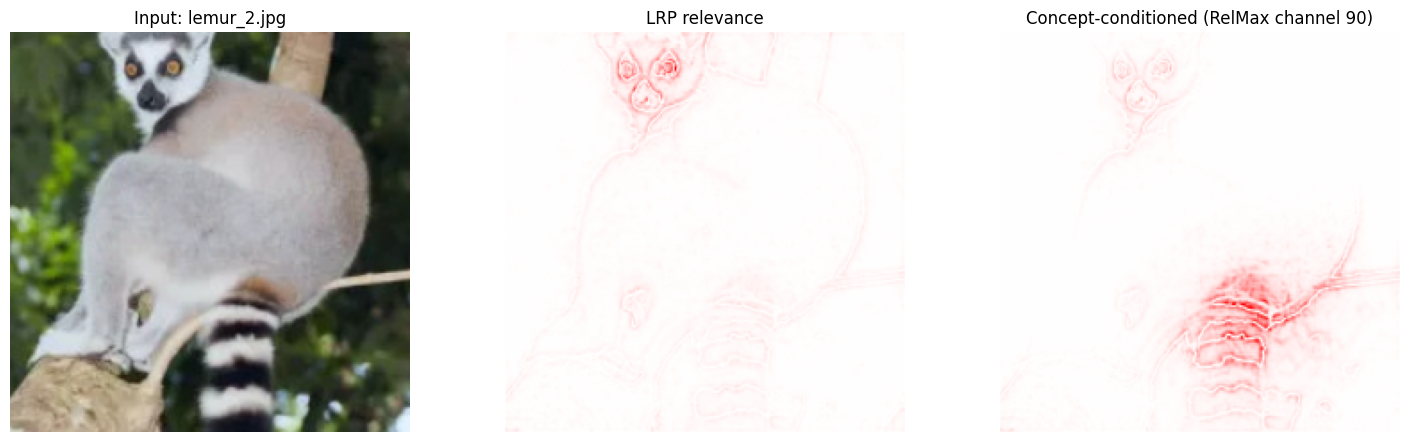

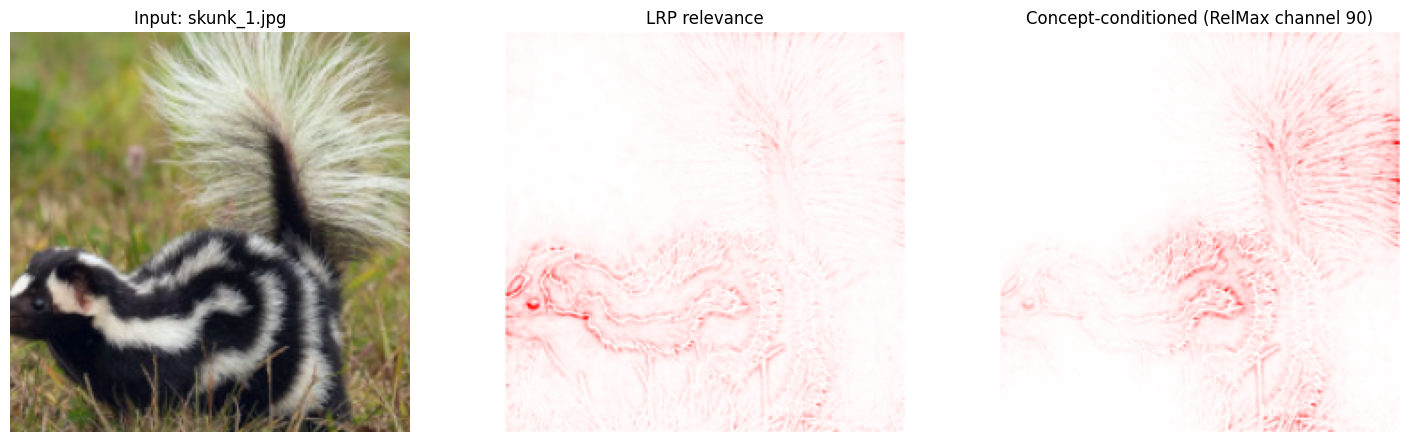

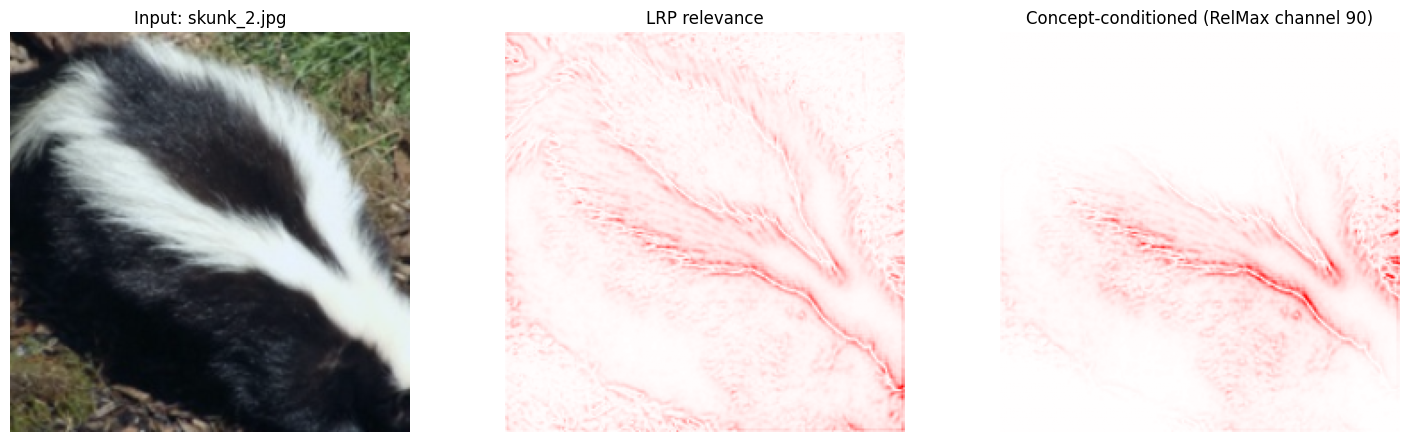

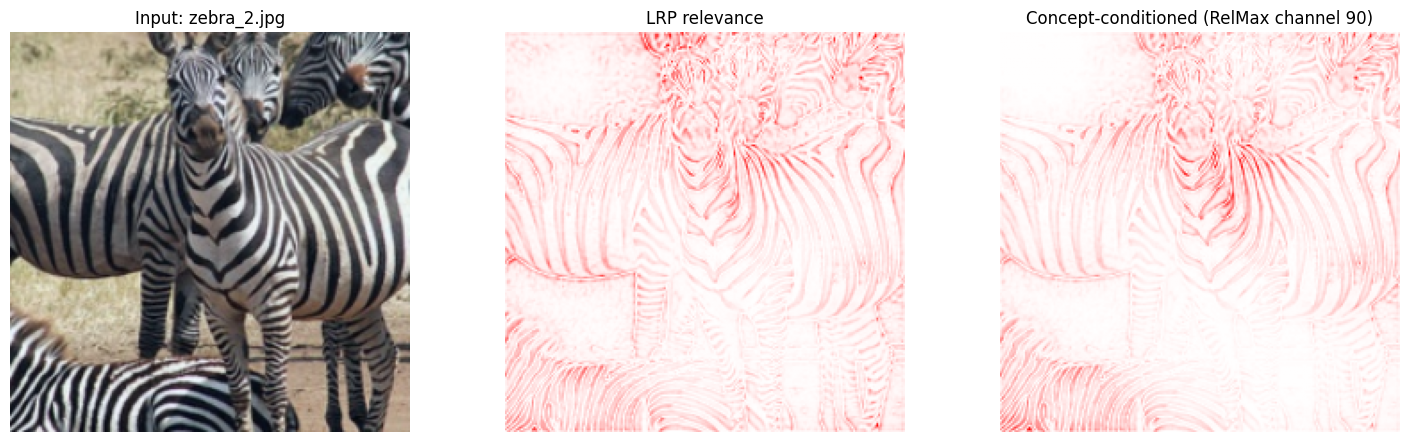

In [10]:
for filename in asset_files:
    image_path = asset_dir / filename
    image = Image.open(image_path).convert("RGB")
    image_tensor = transforms(image)

    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(device))
    target_class = target_class_from_name(filename, logits[0])

    lrp_map = run_lrp_on_image(image_tensor, target_class=target_class, grad_callback=None)
    concept_map = run_lrp_on_image(image_tensor, target_class=target_class, grad_callback=channel_callback)

    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(image_np)
    axes[0].set_title(f"Input: {filename}")
    axes[0].axis("off")

    axes[1].imshow(normalize_heatmap(lrp_map), cmap="bwr", vmin=-1, vmax=1)
    axes[1].set_title("LRP relevance")
    axes[1].axis("off")

    axes[2].imshow(normalize_heatmap(concept_map), cmap="bwr", vmin=-1, vmax=1)
    axes[2].set_title(f"Concept-conditioned (RelMax channel {relmax_channel})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## 4) Interpretation and next steps

What to look for:
- Compare panel 2 vs panel 3: where does relevance become more concentrated?
- Do the concept-conditioned maps emphasize stripe-like regions across animals?
- Which images are ambiguous for the striped concept?

Possible extensions:
- increase the concept dataset size,
- change the analyzed layer,
- use RelMax(k) with `k > 1` to condition on multiple channels.